<a target="_blank" href="https://colab.research.google.com/github/jgromero/dasoc-ap/blob/main/telegram/clasificacion-conspiraciones.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Clasificación de texto

El conjunto de datos utilizado en este ejemplo proviene de la tarea de "Oppositional thinking analysis: Conspiracy theories vs critical thinking narratives" de [PAN 2024](https://pan.webis.de/clef24/pan24-web/oppositional-thinking-analysis.html).

Consiste en una colección de textos extraidos de Telegram anotados manualmente como "críticos" (`OPPOSITIONAL`) frente a "conspirativos" (`CONSPIRACIONAL`).


## Carga de datos

In [9]:
import pandas as pd

data = pd.read_csv('dataset.csv')
data


,text,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL
...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL
3996,I personally do n’t believe Putin would set of...,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL


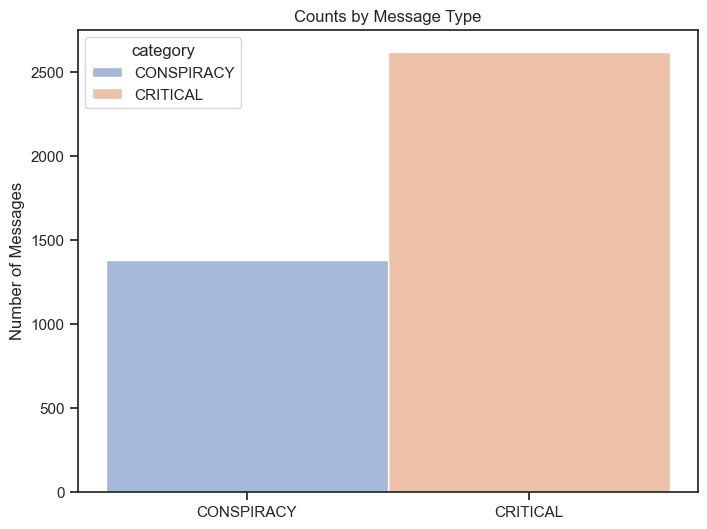

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.set_theme(style="ticks")
sns.histplot(data=data, x='category', hue='category')
plt.title('Counts by Message Type')
plt.xlabel('')
plt.ylabel('Number of Messages')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['category'], test_size=0.2, random_state=42)

## Clasificación usando índices

### Valores enteros como índices

En primer lugar, creamos una capa de codificación de texto con [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/).

Esta capa tiene opciones básicas para gestionar texto en un modelo de Keras. Transforma un conjunto de cadenas en una lista de vectores, en la que cada uno de estos vectores es una lista de números enteros correspondientes a los índices de tokens. 

- Crear [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), especificando diversos parámetros.
- Aplicar [`adapt()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization#adapt) para construir el diccionario a partir de datos.

In [17]:
from keras.layers import TextVectorization

vectorizer = TextVectorization(    
    max_tokens=20000, 
    standardize="lower_and_strip_punctuation",    
    output_mode="int",
    output_sequence_length=200)

vectorizer.adapt(X_train)

ModuleNotFoundError: No module named 'keras'

Esta capa puede codificar secuencias de texto:

In [ ]:
input_data = [
    ["President Trump"], 
    ["Other possible text"]
]
vectorizer(input_data)

In [ ]:
vectorizer.get_vocabulary()

Usando la capa de [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), podemos crear y entrenar un modelo de clasificación.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

model_indices = Sequential([
    vectorizer,    
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_indices.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_indices.fit(X_train, y_train, epochs=10, validation_split=0.2)

In [ ]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')

    # Loss
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history)

### tf-idf

### Codificación _one-hot_

## Clasificación usando _embeddings_

## Clasificación con LLMs